# 7 序贯设计

> **图 7.2**：采用积分均方误差准则（主动学习‑科恩法）对含有两个非活动变量的布兰宁函数进行序贯设计

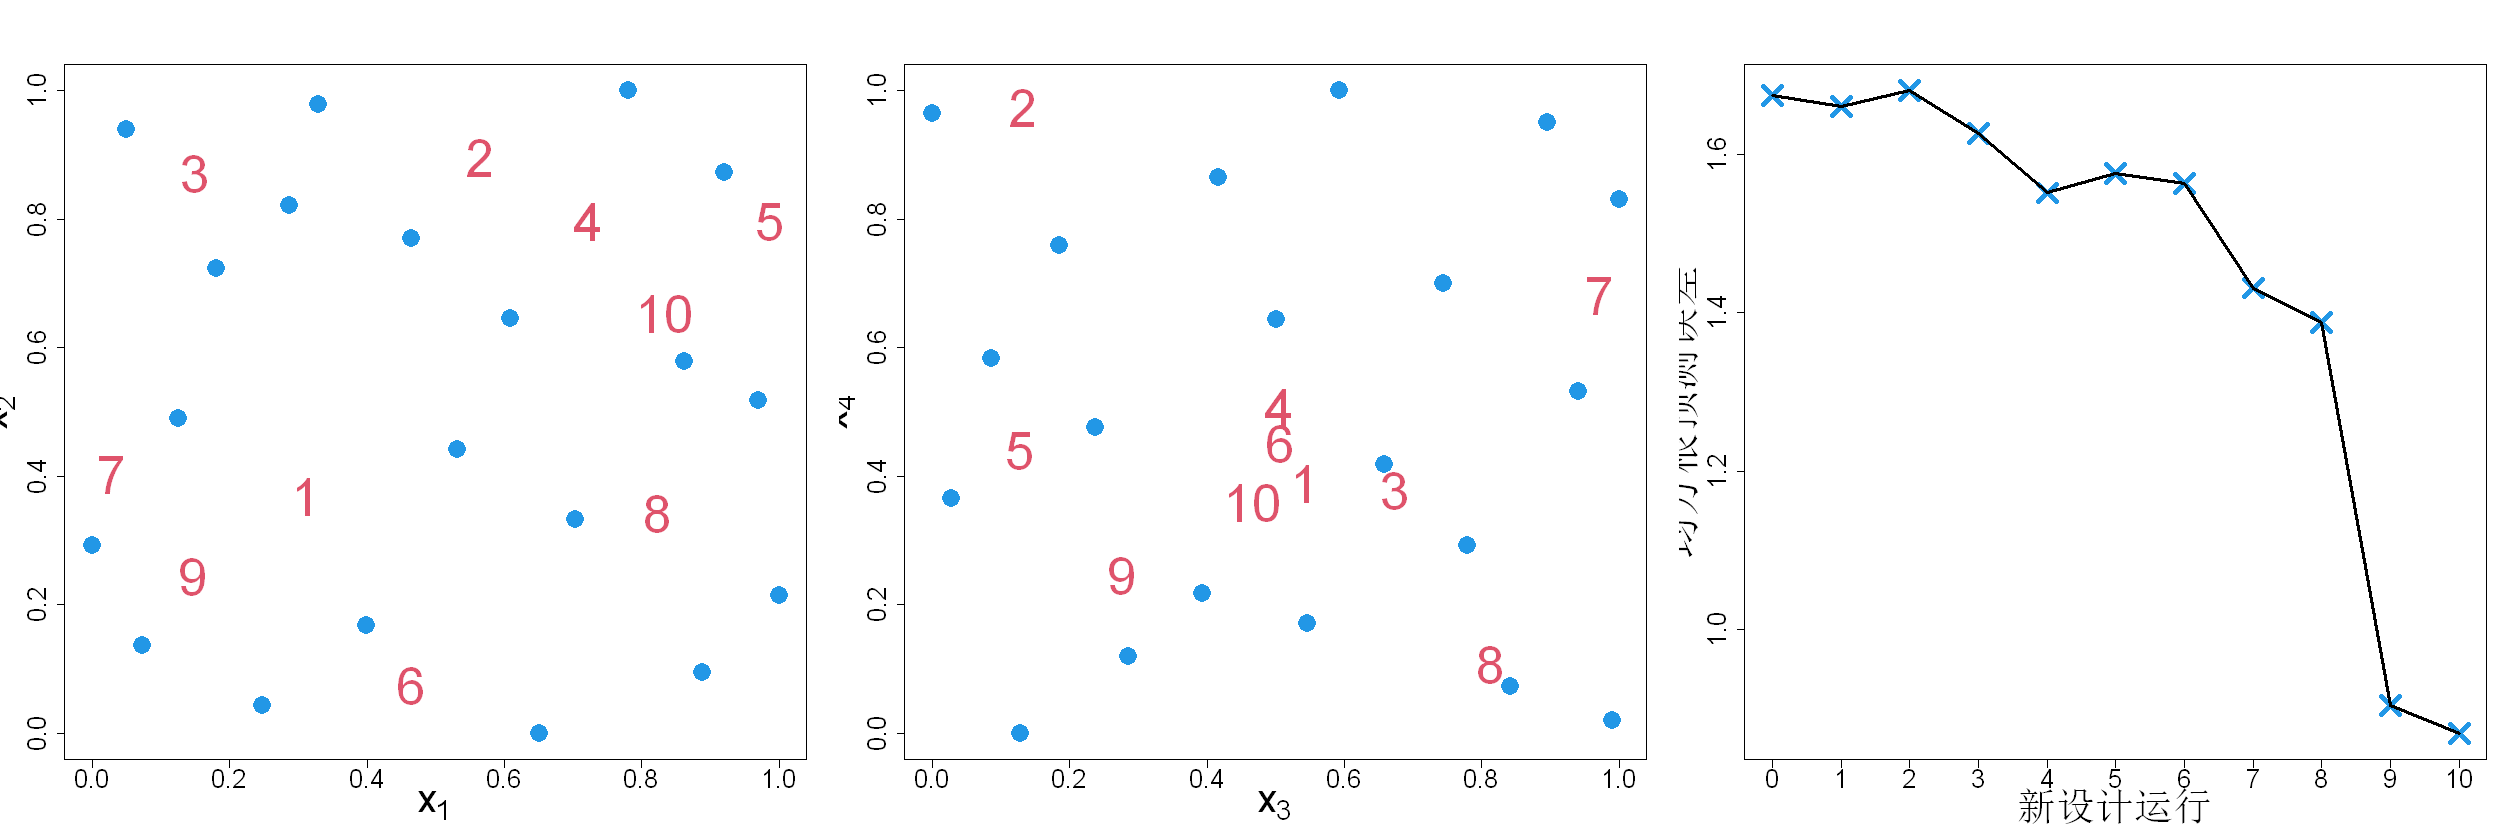

In [1]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/7.2-plot.RData")){
  library(rkriging)
  library(MaxPro)
  library(spacefillr)
  library(FNN)
  library(pdist)
  f=function(x){
    x1=x[1]*15-5
    x2=x[2]*15
    val1=(x2-5.1/(4*pi^2)*(x1^2)+5/pi*x1-6)^2
    val2=10*(1-1/(8*pi))*cos(x1)+10
    return(val1+val2)
  }
  ALC=function(D0,y0,Nnew){
    D=D0
    y=y0
    n=nrow(D0)
    p=ncol(D0)
    test=generate_sobol_set(1000*p,p,seed=sample(10^6,1))
    truey=apply(test,1,f)
    rmse=numeric(Nnew+1)
    for(i in 1:Nnew){
      CAND0=generate_sobol_set(100*p,p,seed=sample(10^6,1))
      if(i==1) theta=rep(1,p)
      kernel=Gaussian.Kernel(theta)
      obj1=Fit.Kriging(D,y,model="OK",kernel=kernel)
      obj2=Fit.Kriging(D,y,kernel.parameters=list(type="Gaussian"))
      if(obj1$get_nllh()<obj2$get_nllh()) obj=obj1 else obj=obj2
      theta=obj$get_lengthscale()
      pred=Predict.Kriging(obj,test)$mean
      rmse[i]=sqrt(mean((pred-truey)^2))
      print(rmse[i])
      kernel=Gaussian.Kernel(theta) 
      R=Evaluate.Kernel(kernel,D)
      Rinv=solve(R+10^(-6)*diag(n))
      r=function(x,theta){
        if(p>1) {
          A=D-rep(1,n)%*%t(x)
          g=exp(-.5*apply(abs(A%*%diag(1/theta))^2,1,sum))
        }else {
          g=exp(-.5*abs((D-x)/theta)^2)
        }
        return(g)
      }
      basis=function(h,theta) exp(-.5*sum((h/theta)^2))
      opt=function(v,theta){
        a=r(v,theta)
        b=c(Rinv%*%a)
        numer=function(x,v,theta){
          val=(basis(x-v,theta)-sum(b*r(x,theta)))^2
          return(val)
        }
        val=mean(apply(CAND0,1,numer,v=v,theta=theta))/max(1-sum(a*b),10^(-6))
        return(val)
      }
      d=c(knn.dist(D,k=1))/2
      dis=as.matrix(pdist(D,CAND0))
      N=dim(CAND0)[1]
      ind=NULL
      for(ii in 1:n) ind=c(ind,(1:N)[dis[ii,]<d[ii]])
      CAND=CAND0[-ind,]
      xnew=CAND[which.max(apply(CAND,1,opt,theta=theta)),]
      D=rbind(D,xnew)
      y=c(y,f(xnew))
      n=n+1
    }
    kernel=Gaussian.Kernel(theta)
    obj1=Fit.Kriging(D,y,model="OK",kernel=kernel)
    obj2=Fit.Kriging(D,y,kernel.parameters=list(type="Gaussian"))
    if(obj1$get_nllh()<obj2$get_nllh()) obj=obj1 else obj=obj2
    theta=obj$get_lengthscale()
    print(theta)
    pred=Predict.Kriging(obj,test)$mean
    rmse[Nnew+1]=sqrt(mean((pred-truey)^2))
    print(rmse[Nnew+1])
    return(list("D"=D,"rmse"=rmse))
  }
  set.seed(1)
  p=4;n=20
  D0=MaxPro(MaxProLHD(n,p)$Design)$Design
  y0=apply(D0,1,f)
  system.time({a=ALC(D0,y0,Nnew=10)})
  D=a$D # 30x4
  rmse=a$rmse # 11x1
  m.D=D
  colnames(m.D)=c("D1","D2","D3","D4")
  save(D,rmse,n,file="data/7.2-plot.RData")
}

load("data/7.2-plot.RData")

options(repr.plot.width=21,repr.plot.height=7)
par(mfrow=c(1,3))
plot(D[1:n,1:2],xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=3,cex.axis=2,pch=16,col=4,cex=3)
points(D[(n+1):(n+10),1:2],col=2,pch=NA)
text(D[(n+1):(n+10),1:2],col=2,labels=1:10,cex=4)
plot(D[1:n,3:4],xlim=c(0,1),ylim=c(0,1),xlab=expression(x[3]),ylab=expression(x[4]),cex.lab=3,cex.axis=2,pch=16,col=4,cex=3)
points(D[(n+1):(n+10),3:4],col=2,pch=NA)
text(D[(n+1):(n+10),3:4],col=2,labels=1:10,cex=4)
plot(1:11,rmse,pch=4,xaxt="n",xlab="新设计运行",ylab="均方根预测误差",cex.lab=3,cex.axis=2,col=4,cex=3,lwd=4)
lines(1:11,rmse,lwd=3)
axis(1,at=1:11,labels=0:10,cex.axis=2)

> **图 7.3**：采用最小均方误差准则对含有两个无效变量的布兰宁函数进行序贯设计

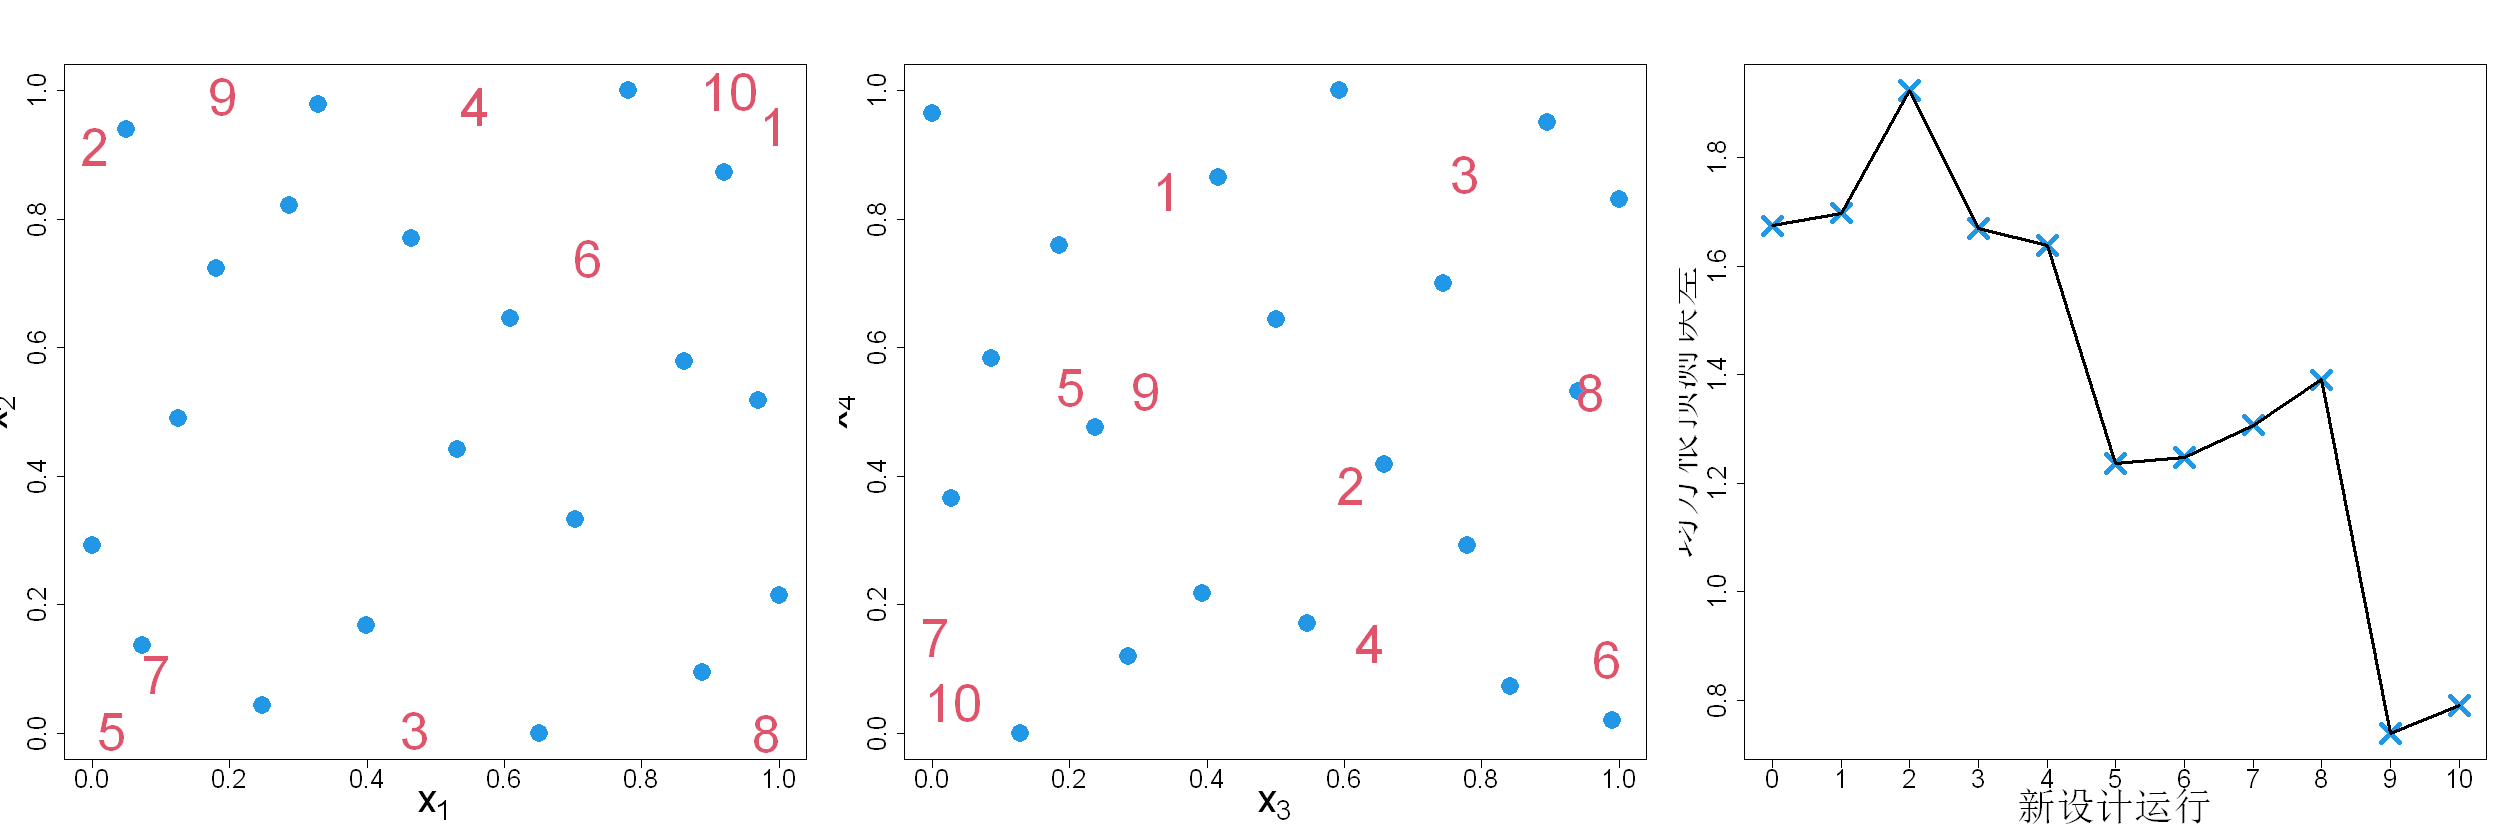

In [2]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/7.3-plot.RData")){
  library(rkriging)
  library(MaxPro)
  library(spacefillr)
  library(FNN)
  library(pdist)
  f=function(x){
    x1=x[1]*15-5
    x2=x[2]*15
    val1=(x2-5.1/(4*pi^2)*(x1^2)+5/pi*x1-6)^2
    val2=10*(1-1/(8*pi))*cos(x1)+10
    return(val1+val2)
  }
  ALMV=function(D0,y0,Nnew){
    D=D0
    y=y0
    test=generate_sobol_set(1000*p,p,seed=sample(10^6,1))
    truey=apply(test,1,f)
    rmse=numeric(Nnew+1)
    for(i in 1:Nnew){
      CAND0=generate_sobol_set(100*p,p,seed=sample(10^6,1))
      if(i==1) theta=rep(1,p)
      kernel=Gaussian.Kernel(theta)
      obj1=Fit.Kriging(D,y,model="OK",kernel=kernel)
      obj2=Fit.Kriging(D,y,kernel.parameters=list(type="Gaussian"))
      if(obj1$get_nllh()<obj2$get_nllh()) obj=obj1 else obj=obj2
      theta=obj$get_lengthscale()
      #print(theta)
      pred=Predict.Kriging(obj,test)$mean
      rmse[i]=sqrt(mean((pred-truey)^2))
      print(rmse[i])
      kernel=Gaussian.Kernel(theta) 
      R=Evaluate.Kernel(kernel, D)
      U=chol(R+10^(-6)*diag(n))
      r=function(x,theta){
        if(p>1) {
          A=D-rep(1,n)%*%t(x)
          g=exp(-.5*apply(abs(A%*%diag(1/theta))^2,1,sum))}else {
            g=exp(-.5*abs((D-x)/theta)^2)
          }
        return(g)
      }
      basis=function(h,theta) exp(-.5*sum((h/theta)^2))
      
      opt=function(v,theta){
        b=forwardsolve(t(U),r(v,theta))
        numer=function(x,v,theta){
          a=forwardsolve(t(U),r(x,theta))
          val=1-sum(a^2)- (basis(x-v, theta)-sum(a*b))^2/max(1-sum(b^2),10^(-6))
          return(val)
        }
        val=max(apply(CAND0,1,numer,v=v, theta=theta))/max(1-sum(b^2),10^(-6))
        return(val)
      }
      d=c(knn.dist(D,k=1))/2
      dis=as.matrix(pdist(D,CAND0))
      N=dim(CAND0)[1]
      ind=NULL
      for(i in 1:n) ind=c(ind,(1:N)[dis[i,]<d[i]])
      CAND=CAND0[-ind,]
      xnew=CAND[which.min(apply(CAND,1,opt, theta=theta)),]
      D=rbind(D,xnew)
      y=c(y,f(xnew))
      n=n+1
    }
    kernel=Gaussian.Kernel(theta)
    obj1=Fit.Kriging(D,y,model="OK",kernel=kernel)
    obj2=Fit.Kriging(D,y,kernel.parameters=list(type="Gaussian"))
    if(obj1$get_nllh()<obj2$get_nllh()) obj=obj1 else obj=obj2
    theta=obj$get_lengthscale()
    print(theta)
    pred=Predict.Kriging(obj,test)$mean
    rmse[Nnew+1]=sqrt(mean((pred-truey)^2))
    print(rmse[Nnew+1])
    return(list("D"=D,"rmse"=rmse))
  }
  set.seed(1)
  p=4
  n=20
  D0=MaxPro(MaxProLHD(n,p)$Design)$Design
  y0=apply(D0,1,f)
  system.time({a=ALMV(D0,y0,Nnew=10)})
  D=a$D
  rmse=a$rmse
  m.D=D
  colnames(m.D)=c("D1","D2","D3","D4")
  save(D,rmse,n,file="data/7.3-plot.RData")
}

load("data/7.3-plot.RData")

options(repr.plot.width=21,repr.plot.height=7)
par(mfrow=c(1,3))
plot(D[1:n,1:2],xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]), cex.lab=3,cex.axis=2,pch=16,col=4,cex=3)
points(D[(n+1):(n+10),1:2],col=2,pch=NA)
text(D[(n+1):(n+10),1:2],col=2,labels=1:10,cex=4)
plot(D[1:n,3:4],xlim=c(0,1),ylim=c(0,1),xlab=expression(x[3]),ylab=expression(x[4]), cex.lab=3,cex.axis=2,pch=16,col=4,cex=3)
points(D[(n+1):(n+10),3:4],col=2,pch=NA)
text(D[(n+1):(n+10),3:4],col=2,labels=1:10,cex=4)
plot(1:11,rmse,pch=4,xaxt="n",xlab="新设计运行",ylab="均方根预测误差",cex.lab=3,cex.axis=2,col=4,cex=3,lwd=4)
lines(1:11,rmse,lwd=3)
axis(1,at=1:11, labels=0:10,cex.axis=2)

> **图 7.4**：基于熵准则的序贯设计（麦克凯主动学习），针对带有两个非活跃变量的布兰宁函数

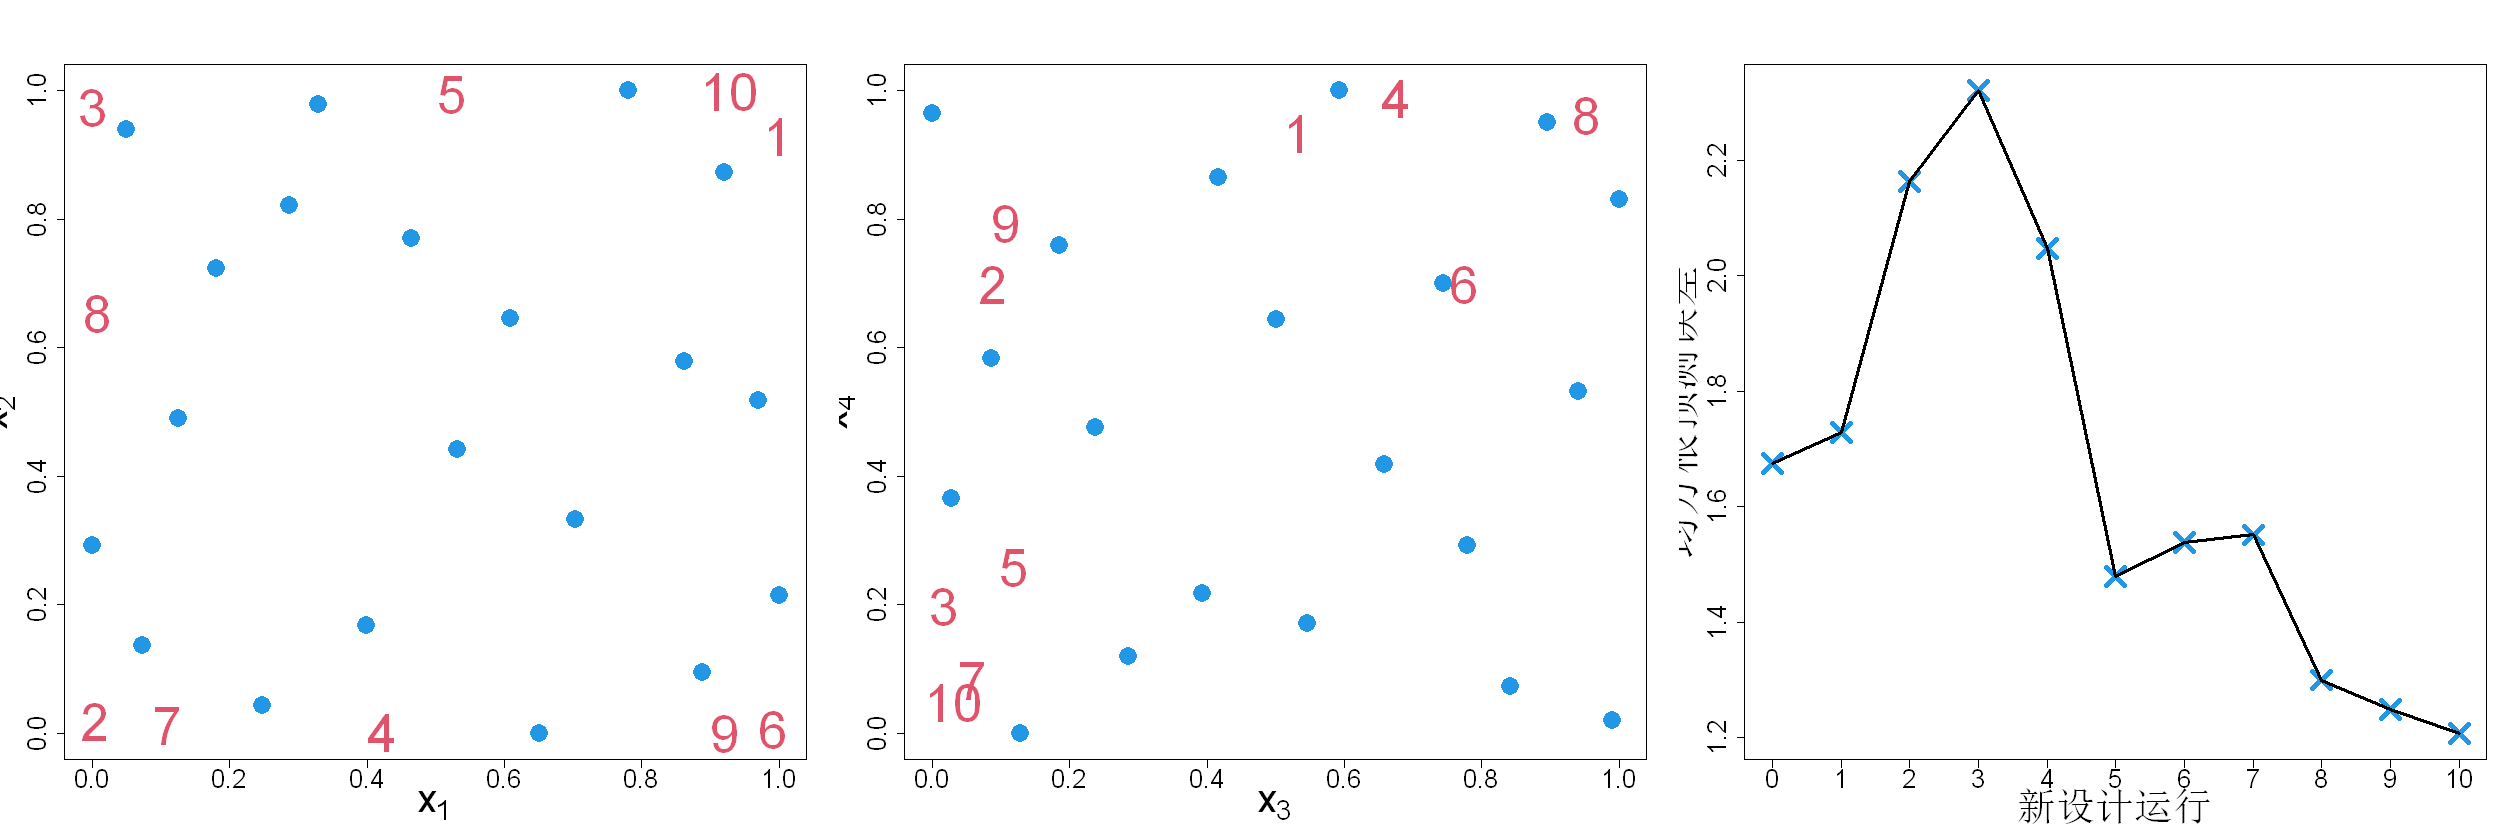

In [3]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/7.4-plot.RData")){
  library(rkriging)
  library(MaxPro)
  library(spacefillr)
  library(FNN)
  library(pdist)
  f=function(x){
    x1=x[1]*15-5
    x2=x[2]*15
    val1=(x2-5.1/(4*pi^2)*(x1^2)+5/pi*x1-6)^2
    val2=10*(1-1/(8*pi))*cos(x1)+10
    return(val1+val2)
  }
  ALM=function(D0,y0,Nnew){
    D=D0
    y=y0
    test=generate_sobol_set(1000*p,p,seed=sample(10^6,1))
    truey=apply(test,1,f)
    rmse=numeric(Nnew+1)
    for(i in 1:Nnew){
      CAND0=generate_sobol_set(1000*p,p,seed=sample(10^6,1))
      if(i==1) theta=rep(1,p)
      kernel=Gaussian.Kernel(theta)
      obj1=Fit.Kriging(D,y,model="OK",kernel=kernel)
      obj2=Fit.Kriging(D,y,kernel.parameters = list(type="Gaussian"))
      if(obj1$get_nllh()<obj2$get_nllh()) obj=obj1 else obj=obj2
      theta=obj$get_lengthscale()
      print(theta)
      pred=Predict.Kriging(obj,test)$mean
      rmse[i]=sqrt(mean((pred-truey)^2))
      print(rmse[i])
      kernel=Gaussian.Kernel(theta) 
      R=Evaluate.Kernel(kernel, D)
      Rinv=solve(R+10^(-6)*diag(n))
      r=function(x,theta){
        if(p>1) {
          A=D-rep(1,n)%*%t(x)
          g=exp(-.5*apply(abs(A%*%diag(1/theta))^2,1,sum))}else g=exp(-.5*abs((D-x)/theta)^2)
        return(g)
      }
      opt=function(v,theta){
        a=r(v,theta)
        b=c(Rinv%*%a)
        val=1-sum(a*b)
        return(val)
      }
      d=c(knn.dist(D,k=1))/2
      dis=as.matrix(pdist(D,CAND0))
      N=dim(CAND0)[1]
      ind=NULL
      for(i in 1:n) ind=c(ind,(1:N)[dis[i,]<d[i]])
      CAND=CAND0[-ind,]
      xnew=CAND[which.max(apply(CAND,1,opt, theta=theta)),]
      D=rbind(D,xnew)
      y=c(y,f(xnew))
      n=n+1
    }
    kernel=Gaussian.Kernel(theta)
    obj1=Fit.Kriging(D,y,model="OK",kernel=kernel)
    obj2=Fit.Kriging(D,y,kernel.parameters = list(type="Gaussian"))
    if(obj1$get_nllh()<obj2$get_nllh()) obj=obj1 else obj=obj2
    theta=obj$get_lengthscale()
    print(theta)
    pred=Predict.Kriging(obj,test)$mean
    rmse[Nnew+1]=sqrt(mean((pred-truey)^2))
    print(rmse[Nnew+1])
    return(list("D"=D,"rmse"=rmse))
  }
  set.seed(1)
  p=4
  n=20
  D0=MaxPro(MaxProLHD(n,p)$Design)$Design
  y0=apply(D0,1,f)
  system.time({a=ALM(D0,y0,Nnew=10)})
  D=a$D
  rmse=a$rmse
  m.D=D
  colnames(m.D)=c("D1","D2","D3","D4")
  save(D,rmse,n,file="data/7.4-plot.RData")
}

load("data/7.4-plot.RData")

options(repr.plot.width=21,repr.plot.height=7)
par(mfrow=c(1,3))
plot(D[1:n,1:2],xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]), cex.lab=3,cex.axis=2,pch=16,col=4,cex=3)
points(D[(n+1):(n+10),1:2],col=2,pch=NA)
text(D[(n+1):(n+10),1:2],col=2,labels=1:10,cex=4)
plot(D[1:n,3:4],xlim=c(0,1),ylim=c(0,1),xlab=expression(x[3]),ylab=expression(x[4]), cex.lab=3,cex.axis=2,pch=16,col=4,cex=3)
points(D[(n+1):(n+10),3:4],col=2,pch=NA)
text(D[(n+1):(n+10),3:4],col=2,labels=1:10,cex=4)
plot(1:11,rmse,pch=4,xaxt="n",xlab = "新设计运行",ylab="均方根预测误差",cex.lab=3,cex.axis=2,col=4,cex=3,lwd=4)
lines(1:11,rmse,lwd=3)
axis(1,at=1:11, labels=0:10,cex.axis=2)

> **图 7.5**：对式 (2.1) 中的一维函数执行期望改进最小化算法的两次迭代

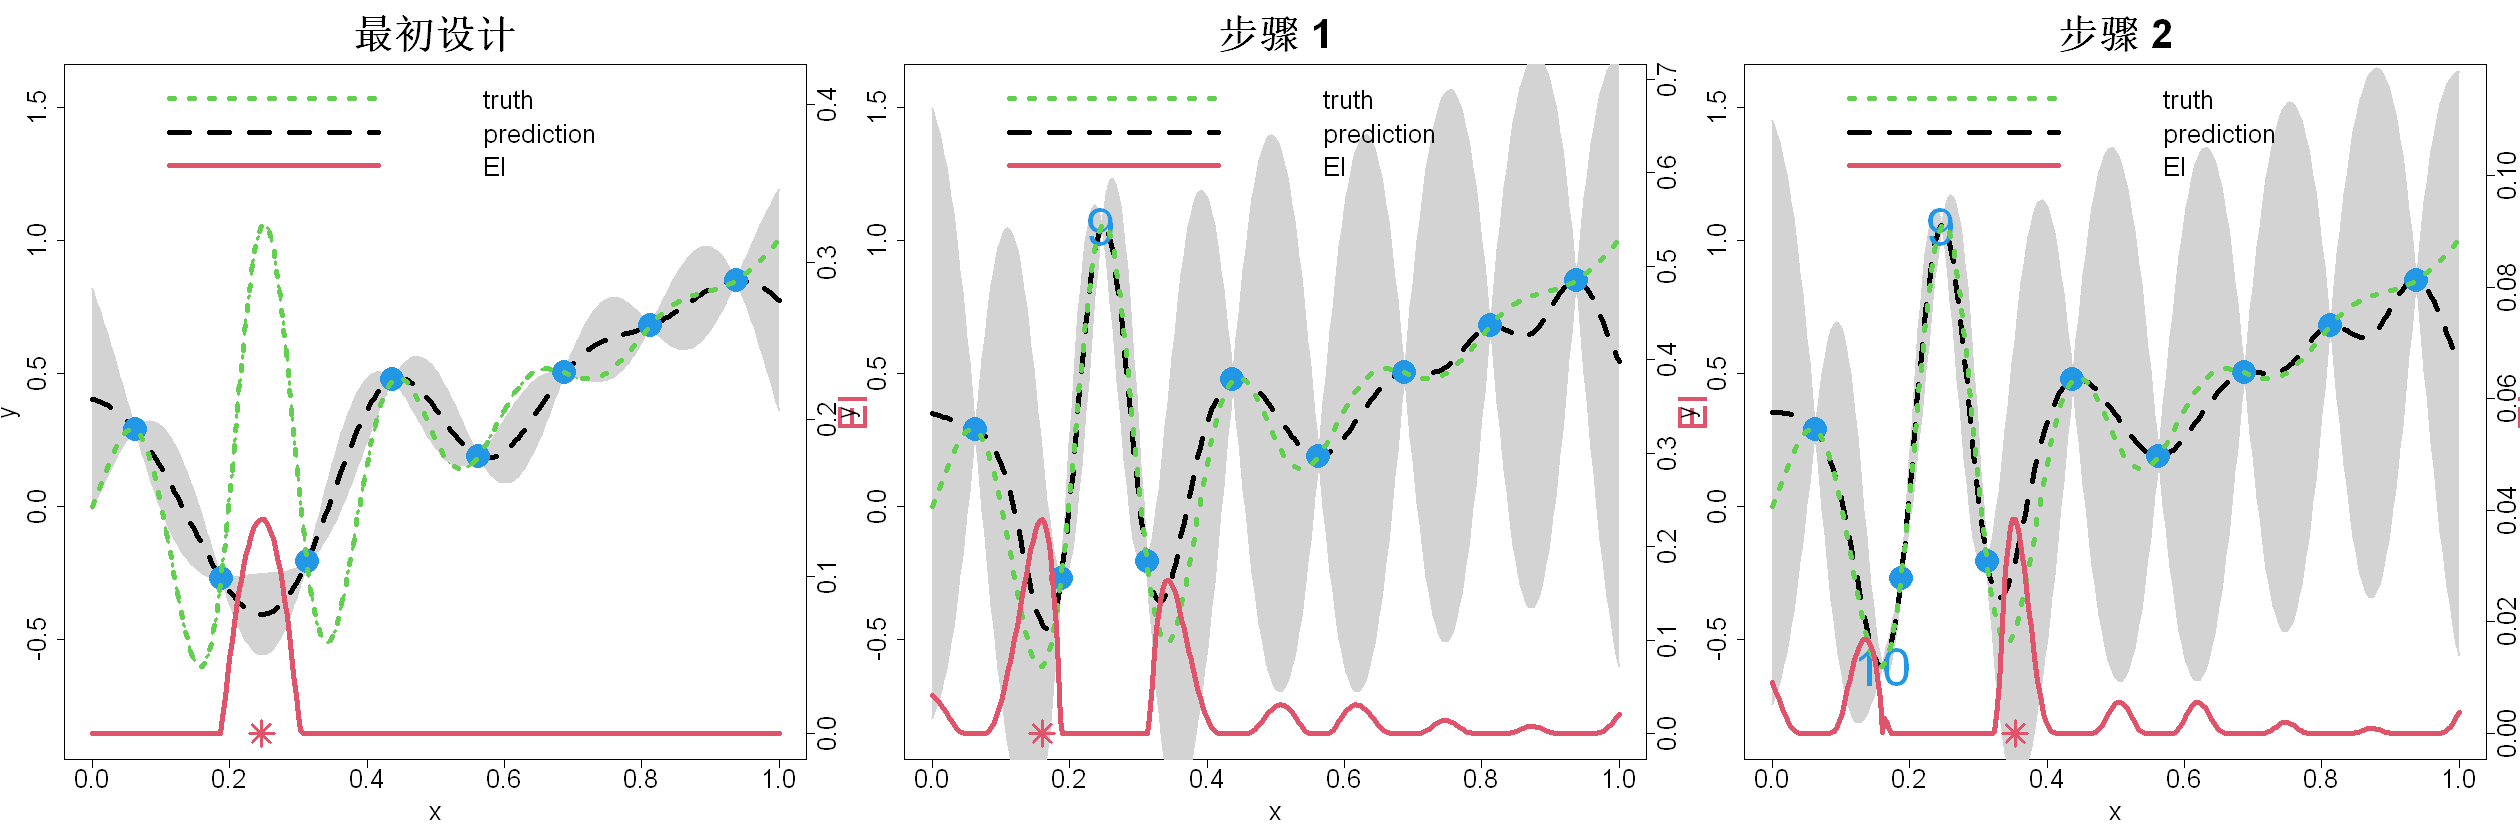

In [4]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/7.5-plot.RData")){
  library(rkriging)
  set.seed(1)
  f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  EI=function(x,hmin,obj){
    pred=Predict.Kriging(obj,cbind(x))
    s=max(pred$sd,10^(-10))
    u=(hmin-pred$mean)/s
    val=s*(u*pnorm(u)+dnorm(u))
    return(val)
  }
  test=seq(0,1,length=301)
  true=f(test)
  n=8
  D=((1:n)-.5)/n
  y=f(D)
  a=Fit.Kriging(D,y,kernel.parameters=list(type="Gaussian"))
  pred=Predict.Kriging(a,test)
  low=pred$mean-2*pred$sd
  up=pred$mean+2*pred$sd
  ei=apply(cbind(test),1,EI,hmin=min(y),obj=a)
  xnew=test[which.max(ei)]
  m.mean=pred$mean
  m.low=low
  m.up=up
  m.ei=ei
  for(i in 1:2){
    D=c(D,xnew)
    y=c(y,f(xnew))
    a=Fit.Kriging(D,y,kernel.parameters=list(type="Gaussian"))
    pred=Predict.Kriging(a,test)
    low=pred$mean-2*pred$sd
    up=pred$mean+2*pred$sd
    ei=apply(cbind(test),1,EI,hmin=min(y),obj=a)
    xnew=test[which.max(ei)]
    m.mean=cbind(m.mean,pred$mean)
    m.low=cbind(m.low,low)
    m.up=cbind(m.up,up)
    m.ei=cbind(m.ei,ei)
  }
  save(D,y,test,true,m.mean,m.low,m.up,m.ei,n,file="data/7.5-plot.RData")
}

load("data/7.5-plot.RData")

options(repr.plot.width=21,repr.plot.height=7)
par(mfrow=c(1,3))

# 初始设计
pred.mean=m.mean[,1]
low=m.low[,1]
up=m.up[,1]
ei=m.ei[,1]
plot(test,true,type="l",xlab="x",ylab="y",lwd=3,lty=3,col=3,ylim=c(min(true)-.25,max(true)+.5),main="最初设计",cex.main=3,cex.axis=2,cex.lab=2)
polygon(c(test,rev(test)),c(low,rev(up)),col="lightgray",border="NA",lwd=2)
lines(test,low,lwd=2,col="lightgray")
lines(test,up,lwd=2,col="lightgray")
lines(test,pred.mean,col=1,lwd=4,lty=2)
points(cbind(D[1:n],y[1:n]),pch=16,cex=4,col=4)
lines(test,true,lty=3,lwd=4,col=3)
legend("topleft",legend=c("truth","prediction","EI"),lty=c(3,2,1),col=c(3,1,2),lwd=c(4,4,4),bty="n",cex=2)

par(new=TRUE)
plot(test,ei,"l",col=2,lwd=4,axes=FALSE,ylim=c(0,3*max(ei)),xlab="",ylab="",cex.axis=2)
axis(side=4,at=pretty(range(3*ei)),cex.axis=2)
mtext("EI",side=4,line=3,cex=2,col=2)
xnew=test[which.max(ei)]
points(xnew,0,col=2,cex=3,pch=8,lwd=3)

# 序贯两步
for(i in 1:2){
  pred.mean=m.mean[,i+1]
  low=m.low[,i+1]
  up=m.up[,i+1]
  ei=m.ei[,i+1]
  plot(test,true,type="l",xlab="x",ylab="y",lwd=3,lty=3,col=3,ylim=c(min(true)-.25,max(true)+.5),main=paste("步骤",i),cex.main=3,cex.axis=2,cex.lab=2)
  polygon(c(test,rev(test)),c(low,rev(up)),col="lightgray",border="NA",lwd=2)
  lines(test,low,lwd=2,col="lightgray")
  lines(test,up,lwd=2,col="lightgray")
  lines(test,pred.mean,col=1,lwd=4,lty=2)
  points(cbind(D[1:n],y[1:n]),pch=16,cex=4,col=4)
  text(cbind(D[(n+1):(n+i)],y[(n+1):(n+i)]),labels=(n+1):(n+i),col=4,cex=4)
  lines(test,true,lty=3,lwd=4,col=3)
  legend("topleft",legend=c("truth","prediction","EI"),lty=c(3,2,1),col=c(3,1,2),lwd=c(4,4,4),bty="n",cex=2)
  par(new=TRUE)
  plot(test,ei,"l",col=2,lwd=4,axes=FALSE,ylim=c(0,3*max(ei)),xlab="",ylab="",cex.axis=2)
  axis(side=4,at=pretty(range(3*ei)),cex.axis=2)
  mtext("EI",side=4,line=3,cex=2,col=2)
  xnew=test[which.max(ei)]
  points(xnew,0,col=2,cex=3,pch=8,lwd=3)
}

> **图 7.6**：针对该逆设计问题，在输入空间内以 10 个点的最大投影拉丁超立方设计（蓝色实心圆）为初始样本，通过序列扰动算法新增了 40 个设计点（红色叉号）

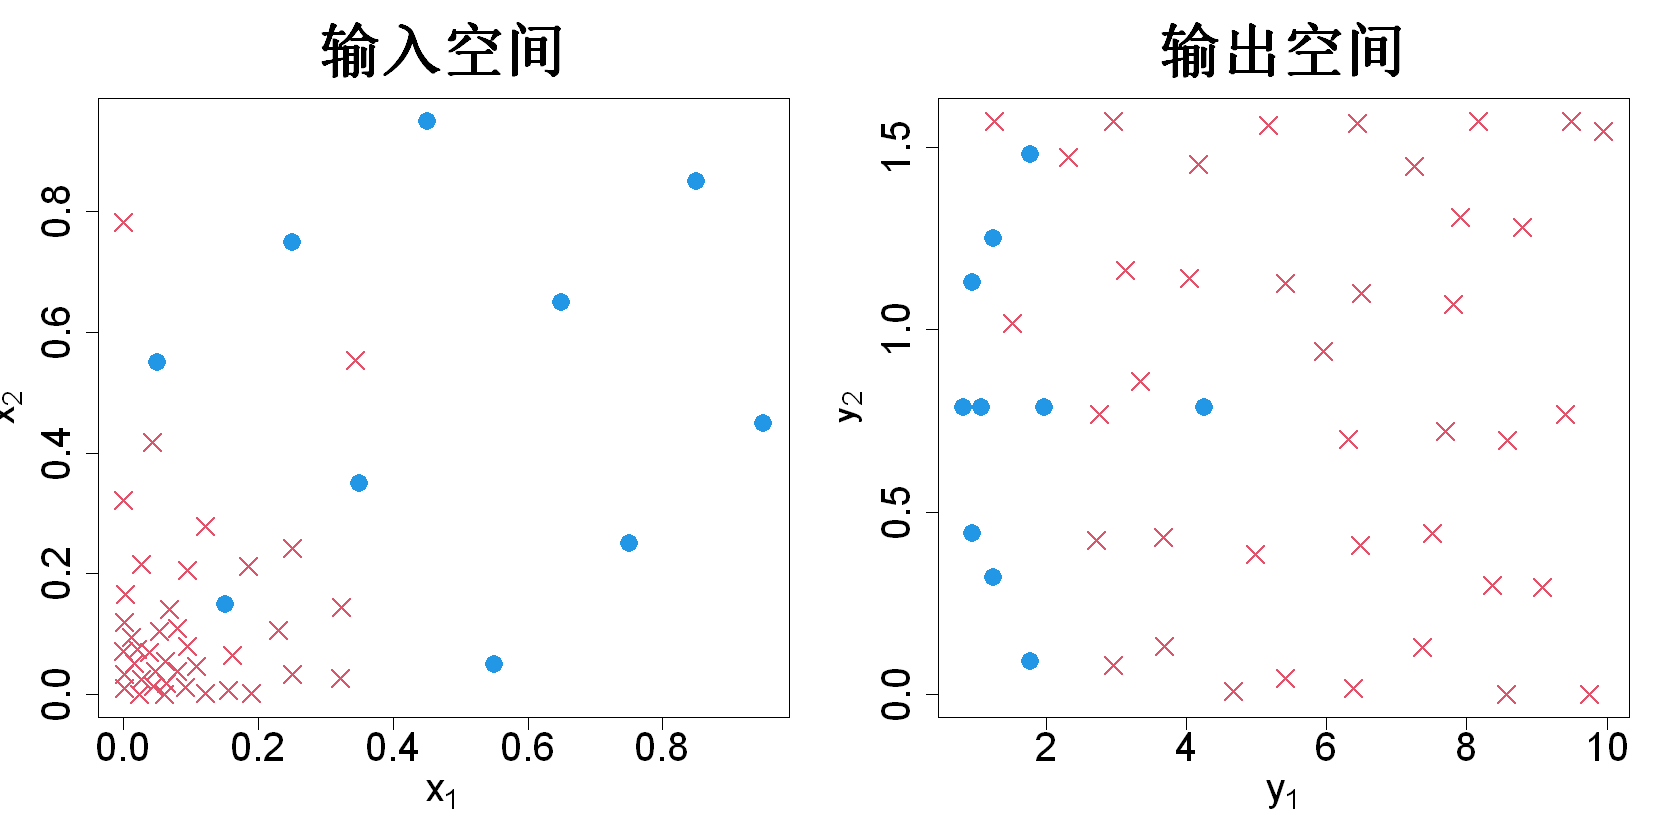

In [5]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/7.6-plot.RData")){
  library(OSFD)
  library(MaxPro)
  f=function(x){
    y1=1/(x[1]^2+x[2]^2+.01)^(1/2)
    if(x[2]==0) y2=0 else if(x[1]==0) y2=pi/2 else y2=atan(x[2]/x[1])
    return(c(y1=y1,y2=y2))
  }
  set.seed(1)
  p=2
  q=2
  n0=10
  n=50
  D0=MaxProLHD(n0,p)$Design
  osfd=OSFD(D=D0,f=f,p=p,q=q,n=n,method="Greedy")
  D=osfd$D
  Y=osfd$Y
  save(D,Y,n0,n,file="data/7.6-plot.RData")
}

load("data/7.6-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(D,pch=NA,main="输入空间",xlab=expression(x[1]),ylab=expression(x[2]),cex.main=3,cex.axis=2,cex.lab=2)
points(D[1:n0,],pch=16,col=4,cex=2)
points(D[(n0+1):n,],pch=4,col=2,lwd=2,cex=2)
plot(Y,pch=NA,main="输出空间",xlab=expression(y[1]),ylab=expression(y[2]),cex.main=3,cex.axis=2,cex.lab=2)
points(Y[1:n0,],pch=16,col=4,cex=2)
points(Y[(n0+1):n,],pch=4,col=2,lwd=2,cex=2)